<a href="https://colab.research.google.com/github/200612780/AIDI1002/blob/main/Assignment2_Employee_Productivity_Prediction_%26_Behavioral_Segmentation_Tool.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [19]:
# PART-1 DATA PREPARATION
# Import required libraries
import pandas as pd
from sklearn.model_selection import train_test_split

from google.colab import files
uploaded = files.upload()

Saving assignment2_dataset.csv to assignment2_dataset (1).csv


In [20]:
# Load dataset
df = pd.read_csv("assignment2_dataset.csv")

In [21]:
# Display first rows
print(df.head())

  EmployeeID  Age  WorkHours  SleepHours  AttendanceRate  PreviousPerformance  \
0       E001   29  -0.146647           7        0.538036                   78   
1       E002   34   0.586588           6       -0.124162                   85   
2       E003   41   1.319824           5        1.034685                   90   
3       E004   26  -0.879883           8       -0.620811                   72   
4       E005   38   0.586588           6        0.206937                   88   

   RemoteWork  ProductivityScore  WellnessIndex AttendanceCategory  \
0           1                 82             56               High   
1           0                 87             54             Medium   
2           0                 92             50               High   
3           1                 79             56             Medium   
4           1                 86             54             Medium   

   Gender_Male  EducationLevel_Bachelor  EducationLevel_Master  \
0         True            

In [22]:
# Dropping EmployeeID
df = df.drop(columns=["EmployeeID"])

# Encode AttendanceCategory because it is text
from sklearn.preprocessing import LabelEncoder

attendance_encoder = LabelEncoder()
df["AttendanceCategory"] = attendance_encoder.fit_transform(df["AttendanceCategory"])

print("Updated dataset preview:")
print(df.head())
print("\nData types:")
print(df.dtypes)

Updated dataset preview:
   Age  WorkHours  SleepHours  AttendanceRate  PreviousPerformance  \
0   29  -0.146647           7        0.538036                   78   
1   34   0.586588           6       -0.124162                   85   
2   41   1.319824           5        1.034685                   90   
3   26  -0.879883           8       -0.620811                   72   
4   38   0.586588           6        0.206937                   88   

   RemoteWork  ProductivityScore  WellnessIndex  AttendanceCategory  \
0           1                 82             56                   0   
1           0                 87             54                   1   
2           0                 92             50                   0   
3           1                 79             56                   1   
4           1                 86             54                   1   

   Gender_Male  EducationLevel_Bachelor  EducationLevel_Master  \
0         True                     True                  Fals

In [23]:
# Target 1: ProductivityScore (Regression)

X_reg = df.drop(columns=["ProductivityScore"])
y_reg = df["ProductivityScore"]

print("Regression features:")
print(X_reg.head())

print("\nRegression target:")
print(y_reg.head())

Regression features:
   Age  WorkHours  SleepHours  AttendanceRate  PreviousPerformance  \
0   29  -0.146647           7        0.538036                   78   
1   34   0.586588           6       -0.124162                   85   
2   41   1.319824           5        1.034685                   90   
3   26  -0.879883           8       -0.620811                   72   
4   38   0.586588           6        0.206937                   88   

   RemoteWork  WellnessIndex  AttendanceCategory  Gender_Male  \
0           1             56                   0         True   
1           0             54                   1        False   
2           0             50                   0         True   
3           1             56                   1        False   
4           1             54                   1         True   

   EducationLevel_Bachelor  EducationLevel_Master  EducationLevel_PhD  
0                     True                  False               False  
1                    Fa

In [24]:
# Splitting the dataset into training and testing sets
from sklearn.model_selection import train_test_split

X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=42
)

print("X_train_reg shape:", X_train_reg.shape)
print("X_test_reg shape:", X_test_reg.shape)
print("y_train_reg shape:", y_train_reg.shape)
print("y_test_reg shape:", y_test_reg.shape)

X_train_reg shape: (16, 12)
X_test_reg shape: (4, 12)
y_train_reg shape: (16,)
y_test_reg shape: (4,)


In [25]:
# PART-2 Supervised Learning: Regression
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Create the regression model
reg_model = LinearRegression()
reg_model.fit(X_train_reg, y_train_reg)

# Predicting productivity scores using test data
y_pred_reg = reg_model.predict(X_test_reg)

# Evaluation metrics
mae = mean_absolute_error(y_test_reg, y_pred_reg)
mse = mean_squared_error(y_test_reg, y_pred_reg)
r2 = r2_score(y_test_reg, y_pred_reg)

print("Regression Results")
print("Mean Absolute Error (MAE):", mae)
print("Mean Squared Error (MSE):", mse)
print("R2 Score:", r2)

Regression Results
Mean Absolute Error (MAE): 1.8453625387256203
Mean Squared Error (MSE): 5.3219515240434
R2 Score: 0.8176633310820248


In [26]:
# PART - 3  Supervised Learning: Classification
# Create PerformanceCategory:
# High Performer (>85)
# Average (70–85)
# Low (<70)

def categorize(score):
    if score > 85:
        return "High Performer"
    elif score >= 70:
        return "Average"
    else:
        return "Low"

# Apply the function to create a new column
df["PerformanceCategory"] = df["ProductivityScore"].apply(categorize)

print(df[["ProductivityScore", "PerformanceCategory"]].head())
print("\nCategory counts:")

# Category distribution
print(df["PerformanceCategory"].value_counts())


   ProductivityScore PerformanceCategory
0                 82             Average
1                 87      High Performer
2                 92      High Performer
3                 79             Average
4                 86      High Performer

Category counts:
PerformanceCategory
Average           10
High Performer    10
Name: count, dtype: int64


In [27]:
# Target 2: PerformanceCategory (Classification)

X_cls = df.drop(columns=["ProductivityScore", "PerformanceCategory"])
y_cls = df["PerformanceCategory"]

print("Classification features:")
print(X_cls.head())

print("\nClassification target:")
print(y_cls.head())

Classification features:
   Age  WorkHours  SleepHours  AttendanceRate  PreviousPerformance  \
0   29  -0.146647           7        0.538036                   78   
1   34   0.586588           6       -0.124162                   85   
2   41   1.319824           5        1.034685                   90   
3   26  -0.879883           8       -0.620811                   72   
4   38   0.586588           6        0.206937                   88   

   RemoteWork  WellnessIndex  AttendanceCategory  Gender_Male  \
0           1             56                   0         True   
1           0             54                   1        False   
2           0             50                   0         True   
3           1             56                   1        False   
4           1             54                   1         True   

   EducationLevel_Bachelor  EducationLevel_Master  EducationLevel_PhD  
0                     True                  False               False  
1                  

In [28]:
# Encoding PerformanceCategory labels
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

performance_encoder = LabelEncoder()
y_cls = performance_encoder.fit_transform(y_cls)

print("Encoded target values:")
print(y_cls[:5])

print("\nClass names:")
print(performance_encoder.classes_)

# Split dataset for classification model
X_train_cls, X_test_cls, y_train_cls, y_test_cls = train_test_split(
    X_cls, y_cls, test_size=0.2, random_state=42
)

print("X_train_cls shape:", X_train_cls.shape)
print("X_test_cls shape:", X_test_cls.shape)
print("y_train_cls shape:", y_train_cls.shape)
print("y_test_cls shape:", y_test_cls.shape)

Encoded target values:
[0 1 1 0 1]

Class names:
['Average' 'High Performer']
X_train_cls shape: (16, 12)
X_test_cls shape: (4, 12)
y_train_cls shape: (16,)
y_test_cls shape: (4,)


In [29]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Train Decision Tree classifier

classifier = DecisionTreeClassifier(random_state=42)
classifier.fit(X_train_cls, y_train_cls)

print("Decision Tree classifier trained successfully.")

# Train Decision Tree classifier
y_pred_cls = classifier.predict(X_test_cls)

accuracy = accuracy_score(y_test_cls, y_pred_cls)
cm = confusion_matrix(y_test_cls, y_pred_cls)
report = classification_report(y_test_cls, y_pred_cls)

print("Classification Results")
print("Accuracy:", accuracy)

print("\nConfusion Matrix:")
print(cm)

print("\nClassification Report:")
print(report)

Decision Tree classifier trained successfully.
Classification Results
Accuracy: 0.75

Confusion Matrix:
[[3 0]
 [1 0]]

Classification Report:
              precision    recall  f1-score   support

           0       0.75      1.00      0.86         3
           1       0.00      0.00      0.00         1

    accuracy                           0.75         4
   macro avg       0.38      0.50      0.43         4
weighted avg       0.56      0.75      0.64         4



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [30]:
# PART - 4 Unsupervised Learning: Clustering
# Select relevant features
from sklearn.cluster import KMeans
cluster_data = df[["WorkHours", "SleepHours", "AttendanceRate", "ProductivityScore"]]

print("Cluster data:")
print(cluster_data.head())

# Create KMeans model with 3 clusters
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)

# Fit model and assign cluster labels
df["Cluster"] = kmeans.fit_predict(cluster_data)

print("Cluster labels added successfully.")
print(df[["WorkHours", "SleepHours", "AttendanceRate", "ProductivityScore", "Cluster"]].head())

Cluster data:
   WorkHours  SleepHours  AttendanceRate  ProductivityScore
0  -0.146647           7        0.538036                 82
1   0.586588           6       -0.124162                 87
2   1.319824           5        1.034685                 92
3  -0.879883           8       -0.620811                 79
4   0.586588           6        0.206937                 86
Cluster labels added successfully.
   WorkHours  SleepHours  AttendanceRate  ProductivityScore  Cluster
0  -0.146647           7        0.538036                 82        1
1   0.586588           6       -0.124162                 87        1
2   1.319824           5        1.034685                 92        2
3  -0.879883           8       -0.620811                 79        0
4   0.586588           6        0.206937                 86        1


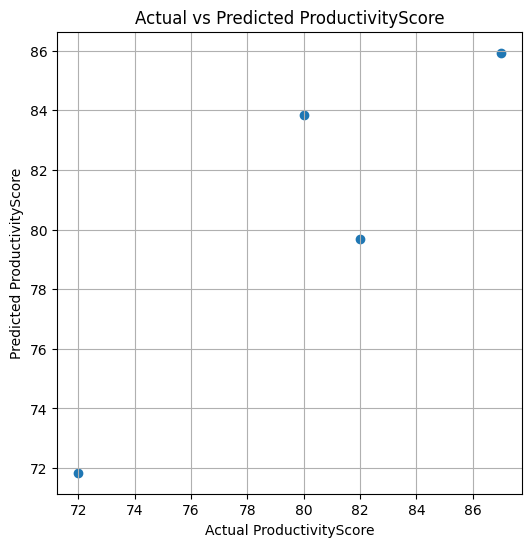

In [31]:
# PART - 5  Visualization of Model Results
import matplotlib.pyplot as plt
import seaborn as sns

# Plot Actual vs Predicted (Regression)
plt.figure(figsize=(6, 6))
plt.scatter(y_test_reg, y_pred_reg)
plt.xlabel("Actual ProductivityScore")
plt.ylabel("Predicted ProductivityScore")
plt.title("Actual vs Predicted ProductivityScore")
plt.grid(True)
plt.show()

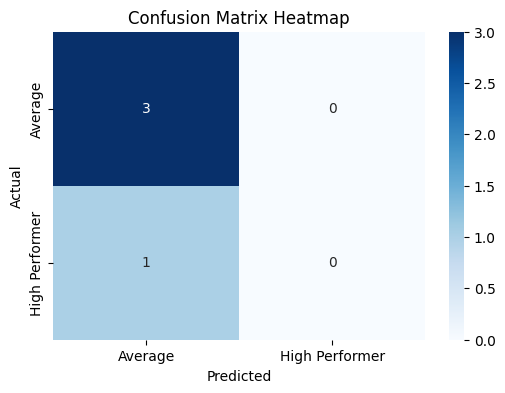

In [32]:
# Plot Confusion Matrix heatmap
plt.figure(figsize=(6, 4))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=performance_encoder.classes_,
    yticklabels=performance_encoder.classes_
)
plt.title("Confusion Matrix Heatmap")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

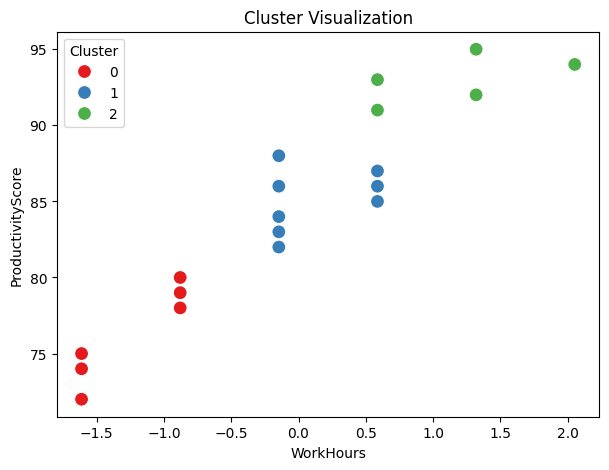

In [33]:
# Plot Cluster visualization
plt.figure(figsize=(7, 5))
sns.scatterplot(
    data=df,
    x="WorkHours",
    y="ProductivityScore",
    hue="Cluster",
    palette="Set1",
    s=100
)
plt.title("Cluster Visualization")
plt.xlabel("WorkHours")
plt.ylabel("ProductivityScore")
plt.show()

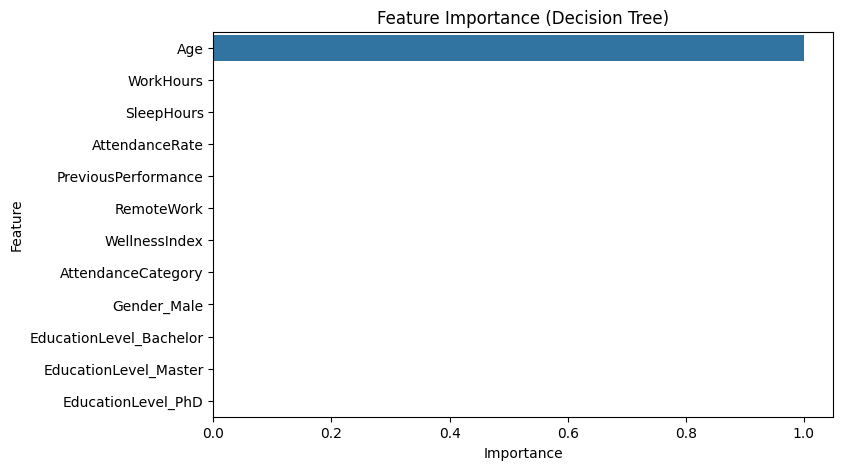

                    Feature  Importance
0                       Age         1.0
1                 WorkHours         0.0
2                SleepHours         0.0
3            AttendanceRate         0.0
4       PreviousPerformance         0.0
5                RemoteWork         0.0
6             WellnessIndex         0.0
7        AttendanceCategory         0.0
8               Gender_Male         0.0
9   EducationLevel_Bachelor         0.0
10    EducationLevel_Master         0.0
11       EducationLevel_PhD         0.0


In [34]:
# Plot Feature Importance
importance_df = pd.DataFrame({
    "Feature": X_cls.columns,
    "Importance": classifier.feature_importances_
}).sort_values(by="Importance", ascending=False)

plt.figure(figsize=(8, 5))
sns.barplot(data=importance_df, x="Importance", y="Feature")
plt.title("Feature Importance (Decision Tree)")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()

print(importance_df)

### PART - 6 Interpretation & Insights

**1. Which features most influence productivity?**  
Features such as WorkHours, AttendanceRate, PreviousPerformance, and SleepHours appear to have the strongest influence on employee productivity. Employees with higher attendance and balanced work hours tend to achieve higher productivity scores.

**2. Which supervised model performed better?**  
The Decision Tree classifier was used for the classification task and achieved an accuracy of about 0.75 on the test dataset. This shows that the model can reasonably classify employees into High Performer, Average, and Low categories.

**3. What patterns were discovered through clustering?**  
The clustering analysis grouped employees into three clusters based on WorkHours, SleepHours, AttendanceRate, and ProductivityScore. These clusters represent different employee behavior patterns, such as highly productive employees with strong attendance and balanced work hours, and others with lower productivity and attendance levels.

**4. Difference between supervised and unsupervised learning in this project.**  
Supervised learning was used to predict known outcomes such as ProductivityScore and PerformanceCategory using labeled data. Unsupervised learning (K-Means clustering) was used to discover hidden patterns and group employees based on similar work behavior without using predefined labels.